## Preprocessing And Feature Engineering

## Check GPU

In [11]:
import subprocess, warnings, platform, os, psutil, gc, time
warnings.filterwarnings('ignore')
try:
    r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                  '--format=csv,noheader'], capture_output=True, text=True)
    if r.returncode == 0:
        print("GPU:", r.stdout.strip())
    else:
        print("CPU ")
        
except FileNotFoundError:
    print("CPU ")

CPU 


In [12]:
print(f"Python  : {platform.python_version()}")
print(f"CPU     : {os.cpu_count()} logical cores")
print(f"RAM     : {psutil.virtual_memory().total/1e9  :.1f} GB total  |  "
      f"{psutil.virtual_memory().available/1e9 :.1f} GB free")

Python  : 3.12.12
CPU     : 4 logical cores
RAM     : 33.7 GB total  |  32.3 GB free


## Install dependencies
same versions as docker deployment version

In [13]:
%%capture
!pip install -q numpy==1.26.4 pandas==2.2.2 matplotlib seaborn scikit-learn==1.5.1 \
  scipy psutil --quiet


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from tqdm.notebook import tqdm
from sklearn.preprocessing import LabelEncoder,RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_class_weight
import joblib
print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")

numpy   1.26.4
pandas  2.2.2


In [15]:
# Directories
working_dir= '/kaggle/working'
plots_dir = '/kaggle/working/plots_preprocessing'
artefacts_dir='/kaggle/working/artefacts'
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(artefacts_dir, exist_ok=True)

## Access Dataset

In [16]:
data_path="/kaggle/input/datasets/aryashah2k/nfuqnidsv2-network-intrusion-detection-dataset/NF-UQ-NIDS-v2.csv"
print(f"Dataset  : {os.path.basename(data_path)}")
print(f"Size     : {os.path.getsize(data_path)/1e9} GB")


Dataset  : NF-UQ-NIDS-v2.csv
Size     : 13.72933023 GB


## Chunked stratified sampling

In [17]:
sample_rate=0.33
chunk_size=500000
random_seed=42
multi_class_target="Attack"  # multi-class attack name
binary_target="Label" # 0 = benign, 1 = attack
#drop non_predictive_features before reading the data
df_features = pd.read_csv(data_path, nrows=0)
all_features   = list(df_features.columns)
non_predictive_features = {'IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'Dataset'}
used_features=[c for c in all_features if c not in non_predictive_features ]

In [18]:
print(f"Total features in The Data : {len(all_features)}")
print(f"Dropped on load       : {non_predictive_features}")
print(f"Features to load      : {len(used_features)}")
print(f"Sample rate: {sample_rate}")

Total features in The Data : 46
Dropped on load       : {'Dataset', 'IPV4_SRC_ADDR', 'IPV4_DST_ADDR'}
Features to load      : 43
Sample rate: 0.33


In [19]:
#dtype map to cast every numerical feature column to float2 instead of pandas default float64 — this halves memory usage for numerical columns.
dtype_map={
    c: 'float32'
    for c in used_features
    if c not in (binary_target,multi_class_target) 
}

#Strips whitespace/newlines from attack name strings.
def parse_multi_class(x):
    return str(x).strip()
    
#converts binary label to int,Returns -1 for any malformed/missing.
def parse_binary_class(x):
    s=str(x).strip()
    if s in ('', 'nan', 'NaN', 'NULL'):
        return -1
    try:
        return int(float(s))
    except ValueError:
        return -1
converters={
    binary_target:parse_binary_class,
    multi_class_target:parse_multi_class
}    

In [20]:
# Counting rows
with open(data_path, 'r') as f:
    total_rows = sum(1 for _ in f) - 1 
n_chunks = (total_rows // chunk_size) + 1
print(f"Estimated rows : {total_rows:,}")
print(f"Estimated chunks : {n_chunks:,}\n")


Estimated rows : 75,987,976
Estimated chunks : 152



In [21]:
csv_iter = pd.read_csv(
    data_path,
    chunksize=chunk_size,
    usecols=used_features,
    dtype=dtype_map,
    converters=converters,
    low_memory=False,
)

In [22]:
chunks = []
for chunk in tqdm(csv_iter,total=n_chunks, desc="Loading chunks"):
    chunk.drop_duplicates(inplace=True)
    sampled=(
        chunk.groupby(multi_class_target,group_keys=False)
        .apply(
            lambda x: x.sample(
                     n=max(1, int(len(x) * sample_rate)),
                     random_state=random_seed
                 )
        )
    )
    chunks.append(sampled)

df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()
before = len(df) 
print(f"Before dropping duplicates : {before:,}")
df.drop_duplicates(keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"After dropping duplicates  : {len(df):,}")
print(f"Dropped      : {before - len(df):,}")
print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

Loading chunks:   0%|          | 0/152 [00:00<?, ?it/s]

Before dropping duplicates : 24,922,530
After dropping duplicates  : 22,822,550
Dropped      : 2,099,980
Shape : 22,822,550 rows × 43 columns


In [23]:
# see if there is any corrupted target
bad_binary = (df[binary_target] == -1).sum()
bad_label  = (df[multi_class_target] == '').sum()
print(bad_binary)
print(bad_label)

0
0


## Separate Features and Labels

In [24]:
feature_cols=[col for col in used_features if col not in (binary_target, multi_class_target)]
numerical_cols = df[feature_cols].select_dtypes(include=np.number).columns.tolist()
print(f"Feature columns  : {len(feature_cols)}")
print(f"Numerical        : {len(numerical_cols)}")

Feature columns  : 41
Numerical        : 41


## Imputing Missing Values


In [25]:
print(f"total nuumber of inf values:{np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")

total nuumber of inf values:125


In [26]:
print(f"total nuumber of inf values:{np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"Inf values after replacement : {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")
print(f"NaN after inf replacement : {df.isnull().sum().sum()}")

total nuumber of inf values:125
Inf values after replacement : 0
NaN after inf replacement : 125


In [27]:
imputer=SimpleImputer(strategy="median")
df[numerical_cols]=imputer.fit_transform(df[numerical_cols]).astype(np.float32)
joblib.dump(imputer, f'{artefacts_dir}/imputer.pkl')
gc.collect()

0

In [28]:
print(f"NaN after imputation : {df.isnull().sum().sum()}")

NaN after imputation : 0


## Feature Engineering

In [29]:
eps = np.float32(1e-4)

# average payload size per incoming packet ,small = scan/flood, large = data transfer
df["bytes_per_pkt_in"] = (df["IN_BYTES"] / (df["IN_PKTS"] + eps)).astype(np.float32)

# average payload size per outgoing packet
df['bytes_per_pkt_out'] = (df["OUT_BYTES"] / (df["OUT_PKTS"] + eps)).astype(np.float32)

# upload to download ratio , high = exfiltration, 1 = botnet beaconing
df["upload_ratio"] = (df["OUT_BYTES"] / (df["IN_BYTES"] + eps)).astype(np.float32)

# byte direction imbalance normalised 0-1 — near 1 = one-directional flood (DDoS)
df['byte_asymmetry'] = (np.abs(df["IN_BYTES"] - df["OUT_BYTES"]) / ((df["IN_BYTES"] + df["OUT_BYTES"]) + eps)).astype(np.float32)

# packet direction imbalance normalised 0-1 , near 1 = SYN flood with no replies
df['pkt_asymmetry'] = (np.abs(df["IN_PKTS"] - df["OUT_PKTS"]) / ((df["IN_PKTS"] + df["OUT_PKTS"]) + eps)).astype(np.float32)

# flags web ports (80,443,8080,8443) , C2 traffic often hides on these ports
df['is_http_https'] = np.isin(df['L4_DST_PORT'], [80, 443, 8080, 8443]).astype(np.float32)

# flags SSH(22) and Telnet(23) , primary targets of brute force and IoT botnet recruitment
df['is_ssh_telnet'] = np.isin(df['L4_DST_PORT'], [22, 23]).astype(np.float32)

# flags DNS port(53) , used in DNS amplification attacks
df['is_dns'] = (df['L4_DST_PORT'] == 53).astype(np.float32)

# TTL variation within flow , non-zero indicates spoofed source addresses
df['ttl_range'] = (df['MAX_TTL'] - df['MIN_TTL']).astype(np.float32)

# SYN flag only set with no ACK , classic half-open SYN flood signature
df['syn_only_flag'] = (df['TCP_FLAGS'] == 2).astype(np.float32)

# difference between largest and smallest packet , near zero = automated scripted traffic
df['pkt_size_range'] = (df['LONGEST_FLOW_PKT'] - df['SHORTEST_FLOW_PKT']).astype(np.float32)

# retransmitted bytes as fraction of total incoming bytes , high = stressed or attacked service
df['retransmit_ratio'] = (df['RETRANSMITTED_IN_BYTES'] / (df["IN_BYTES"] + eps)).astype(np.float32)

# retransmitted packets as fraction of total incoming packets
df['retransmit_pkt_ratio'] = (df['RETRANSMITTED_IN_PKTS'] / (df["IN_PKTS"] + eps)).astype(np.float32)


In [30]:
new_features = [
    'bytes_per_pkt_in', 'bytes_per_pkt_out', 'upload_ratio',
    'byte_asymmetry', 'pkt_asymmetry', 'is_http_https',
    'is_ssh_telnet', 'is_dns', 'ttl_range', 'syn_only_flag',
    'pkt_size_range', 'retransmit_ratio', 'retransmit_pkt_ratio'
]

In [31]:
# Updated numerical_cols
numerical_cols = [c for c in df.columns if c not in (binary_target, multi_class_target)]

In [32]:
# check missing Values 
print(f"Engineered features : {len(new_features)}")
print(f"NaN : {df[new_features].isnull().sum().sum()}")
print(f"Inf : {np.isinf(df[new_features].values).sum()}")

Engineered features : 13
NaN : 0
Inf : 0


## Correlation Matrix

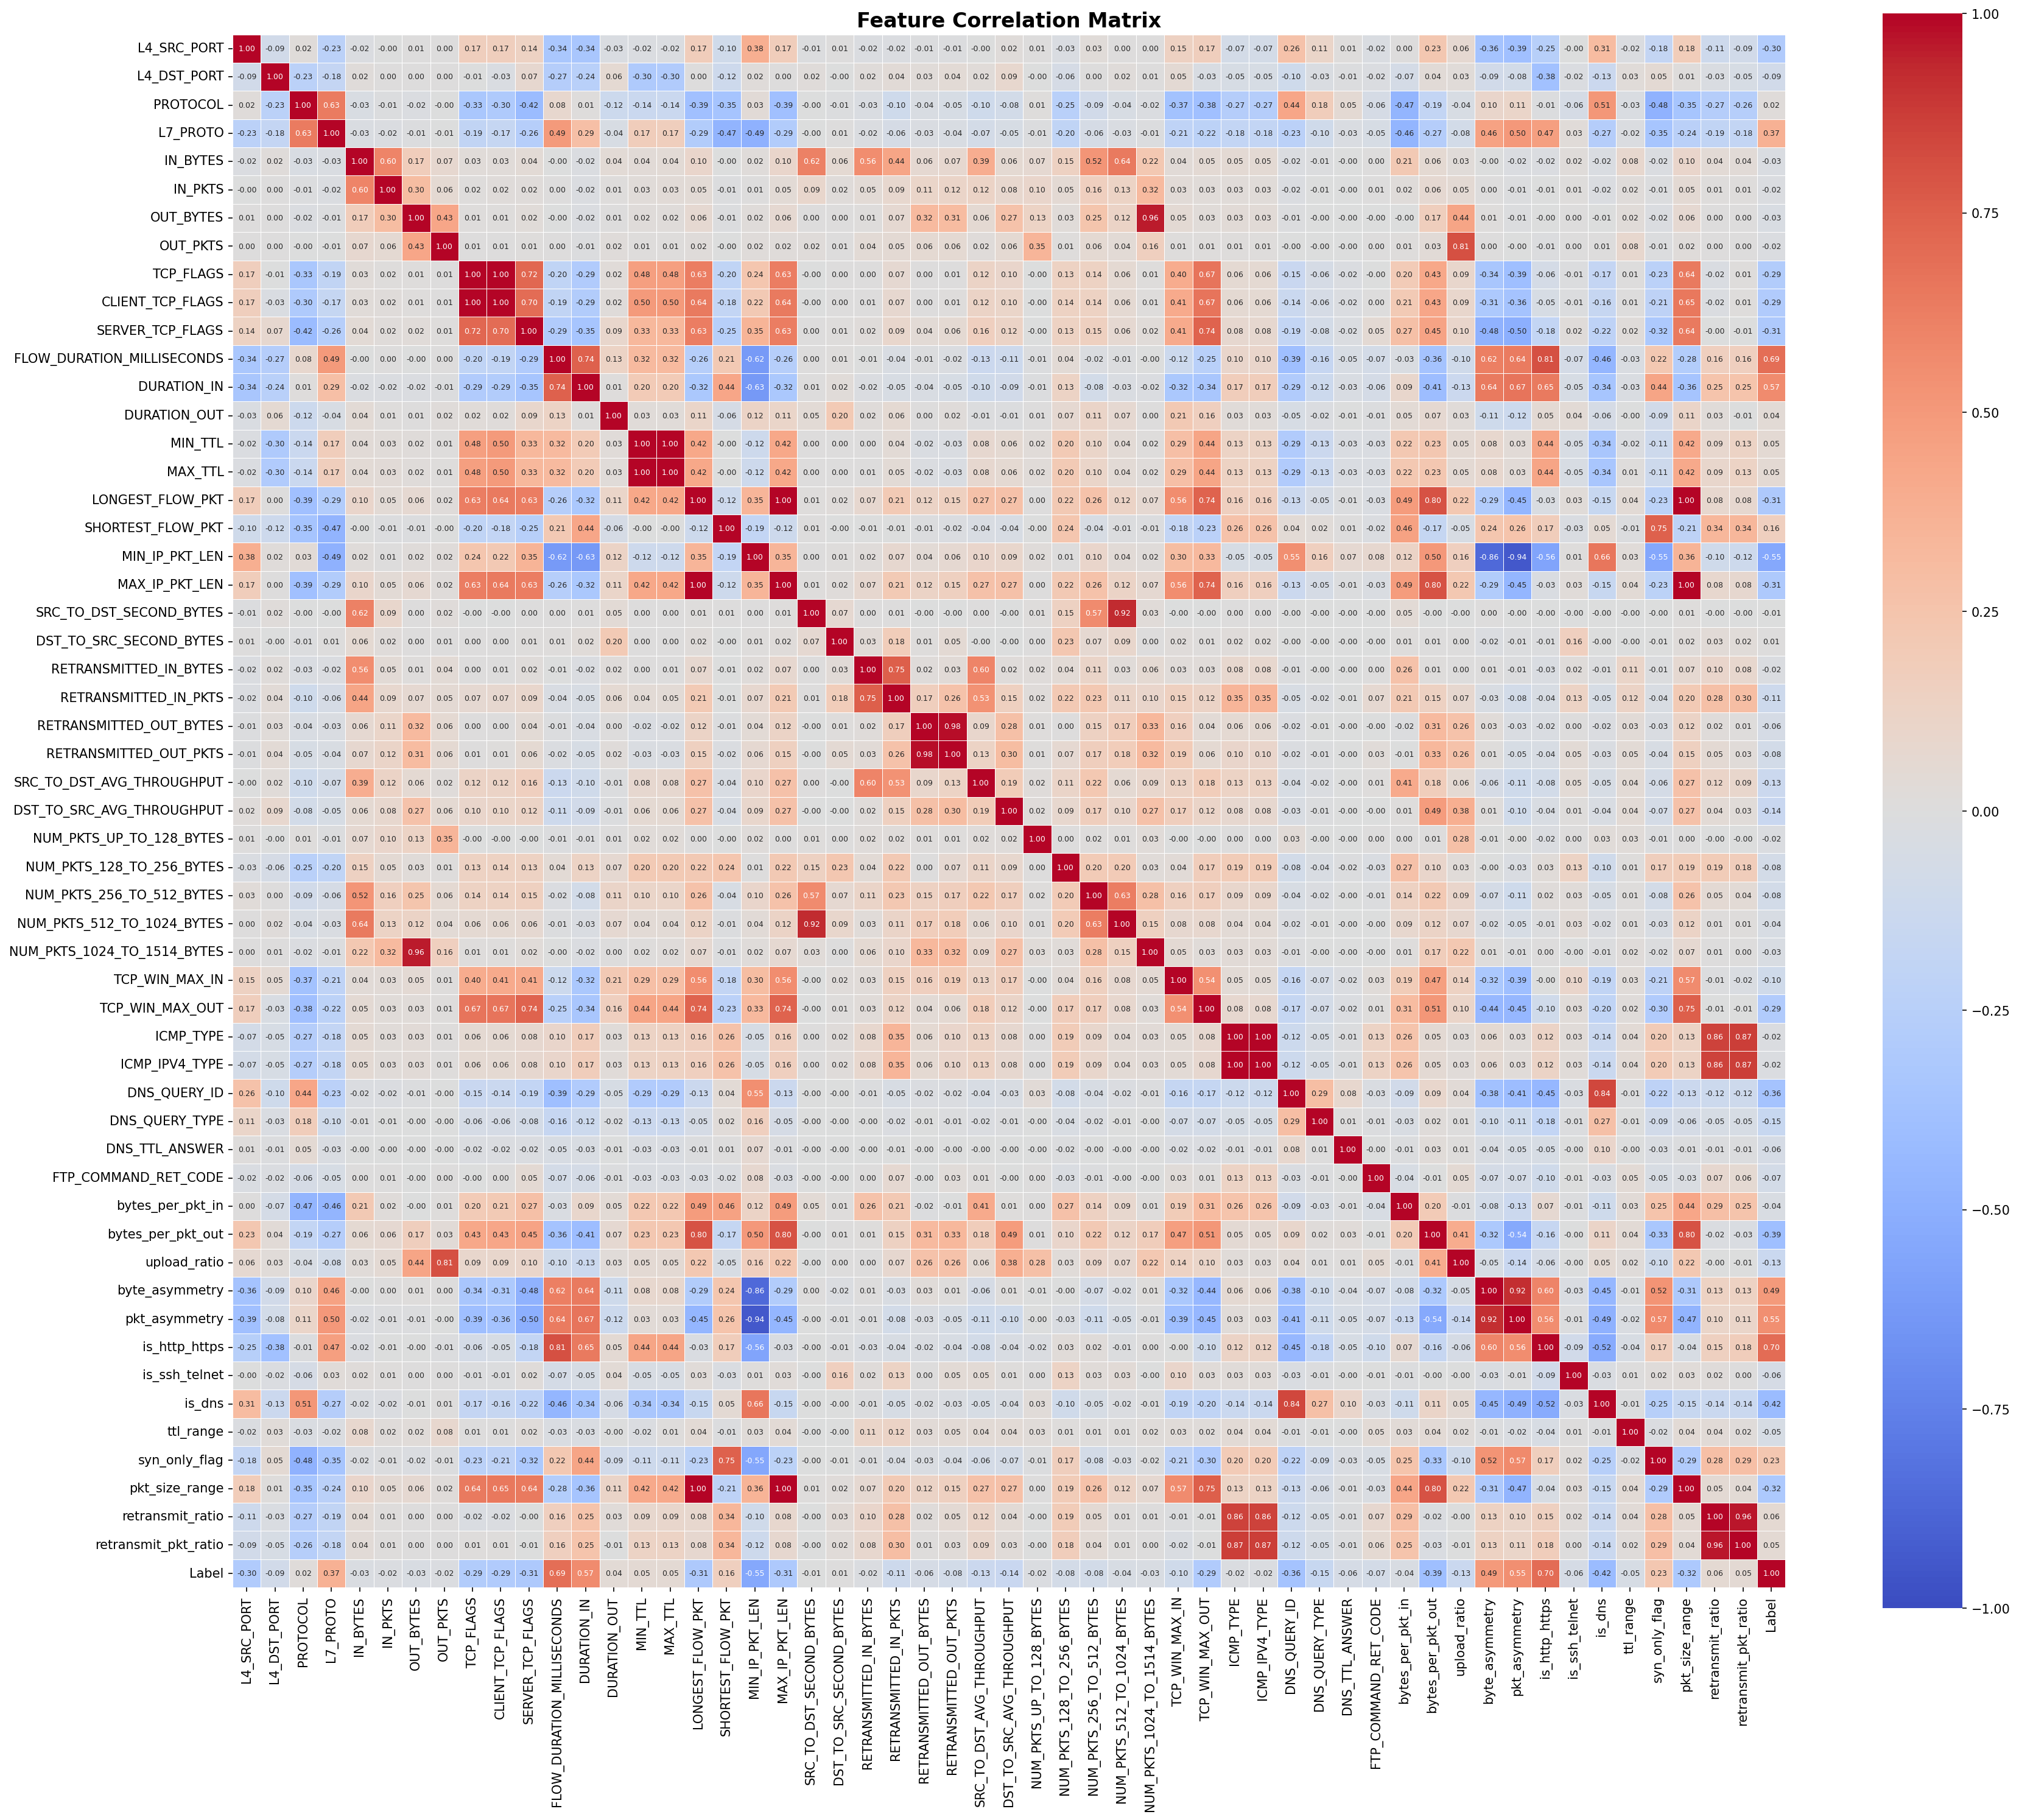

In [33]:
 corr_matrix = df[list(numerical_cols) + [binary_target]].sample(
    n=50_000, random_state=random_seed
).corr()

fig, ax = plt.subplots(figsize=(24, 20), dpi=150) # Increased size slightly so label text fits
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    annot=True,         
    fmt='.2f',        
    annot_kws={"size": 6},
    ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## Check For Multicollinearity

In [34]:
# find pairs with correlation > 0.95 — candidate for removal
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0':'Feature A','level_1':'Feature B', 0:'Correlation'})
    .query('Correlation.abs() > 0.95')
)

high_corr = high_corr[
    (high_corr['Feature A'] != binary_target) & 
    (high_corr['Feature B'] != binary_target)
].sort_values('Correlation', ascending=False)

print(f"Highly correlated pairs (>0.95) excluding label: {len(high_corr)}")
print(high_corr.to_string(index=False))


Highly correlated pairs (>0.95) excluding label: 9
              Feature A                   Feature B  Correlation
       LONGEST_FLOW_PKT              MAX_IP_PKT_LEN     1.000000
              ICMP_TYPE              ICMP_IPV4_TYPE     1.000000
                MIN_TTL                     MAX_TTL     0.999494
              TCP_FLAGS            CLIENT_TCP_FLAGS     0.995533
       LONGEST_FLOW_PKT              pkt_size_range     0.995394
         MAX_IP_PKT_LEN              pkt_size_range     0.995394
RETRANSMITTED_OUT_BYTES      RETRANSMITTED_OUT_PKTS     0.983480
       retransmit_ratio        retransmit_pkt_ratio     0.961268
              OUT_BYTES NUM_PKTS_1024_TO_1514_BYTES     0.956922


In [35]:
corr_drops = [
    'MAX_IP_PKT_LEN',
    'ICMP_IPV4_TYPE',
    'MAX_TTL',
    'CLIENT_TCP_FLAGS',
    'LONGEST_FLOW_PKT',
    'RETRANSMITTED_OUT_PKTS',
    'retransmit_pkt_ratio',
    'NUM_PKTS_1024_TO_1514_BYTES',
]

before = df.shape[1]
df.drop(columns=corr_drops, inplace=True)
numerical_cols = [c for c in df.columns
                  if c not in (binary_target, multi_class_target, 'multi_target_encoded')]

print(f"Dropped         : {len(corr_drops)} features")
print(f"Features before : {before}")
print(f"Features after  : {df.shape[1]}")
# Save for inference pipeline ,apply same drops at inference time
joblib.dump(corr_drops, f'{artefacts_dir}/corr_dropped_cols.pkl')
gc.collect()

Dropped         : 8 features
Features before : 56
Features after  : 48


7

## Encoding Target Labels 

In [36]:
le = LabelEncoder()
df['multi_target_encoded'] = le.fit_transform(df[multi_class_target])
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

for name, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f"{code} : {name}")
    
joblib.dump(le, f'{artefacts_dir}/label_encoder.pkl')

0 : Analysis
1 : Backdoor
2 : Benign
3 : Bot
4 : Brute Force
5 : DDoS
6 : DoS
7 : Exploits
8 : Fuzzers
9 : Generic
10 : Infilteration
11 : Reconnaissance
12 : Shellcode
13 : Theft
14 : Worms
15 : injection
16 : mitm
17 : password
18 : ransomware
19 : scanning
20 : xss


['/kaggle/working/artefacts/label_encoder.pkl']

## Skewness And Log Transformation

In [37]:
skew_vals    = df[numerical_cols].skew().abs()
log_features = skew_vals[skew_vals > 1.0].index.tolist()

print(f"Features to log transform : {len(log_features)}")

for col in log_features:
    df[col] = np.log1p(df[col].clip(lower=0)).astype(np.float32)

# Save for inference pipeline ,apply same log1p at inference time
joblib.dump(log_features, f'{artefacts_dir}/log_features.pkl')
gc.collect()
print(f"Log1p applied to {len(log_features)} features")

Features to log transform : 37
Log1p applied to 37 features


##  Train / Val / Test Split (60/20/20)

In [38]:
X       = df[numerical_cols].values.astype(np.float32)
y_bin   = df[binary_target].values.astype(np.int8)
y_multi = df['multi_target_encoded'].values.astype(np.int16)
del df
gc.collect()

0

In [39]:
#  80% train+val / 20% test , stratify on multi-class for rare class guarantee
X_trainval, X_test, y_trainval_bin, y_test_bin, y_trainval_multi, y_test_multi = train_test_split(
    X, y_bin, y_multi,
    test_size=0.2,
    random_state=random_seed,
    stratify=y_multi           
)

#  75% train / 25% val from trainval ,final 60/20/20 of total
X_train, X_val, y_train_bin, y_val_bin, y_train_multi, y_val_multi = train_test_split(
    X_trainval, y_trainval_bin, y_trainval_multi,
    test_size=0.25,
    random_state=random_seed,
    stratify=y_trainval_multi
)

del X, y_bin, y_multi, X_trainval, y_trainval_bin, y_trainval_multi
gc.collect()

0

In [40]:
print(f"Train : {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"Val   : {X_val.shape[0]:,} rows  × {X_val.shape[1]} features")
print(f"Test  : {X_test.shape[0]:,} rows  × {X_test.shape[1]} features")



Train : 13,693,530 rows × 46 features
Val   : 4,564,510 rows  × 46 features
Test  : 4,564,510 rows  × 46 features


In [41]:
print(f"Train attack % : {y_train_bin.mean()*100:.2f}%")
print(f"Val   attack % : {y_val_bin.mean()*100:.2f}%")
print(f"Test  attack % : {y_test_bin.mean()*100:.2f}%")

Train attack % : 67.29%
Val   attack % : 67.29%
Test  attack % : 67.29%


In [44]:
# Verify all rare classes exist in every split
print(f"Unique classes — Train: {len(np.unique(y_train_multi))}  "
      f"Val: {len(np.unique(y_val_multi))}  "
      f"Test: {len(np.unique(y_test_multi))}")


Unique classes — Train: 21  Val: 21  Test: 21


## RobustScaler — fitted on training data only

In [45]:
scaler  = RobustScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)  # fit on TRAIN only
X_val   = scaler.transform(X_val).astype(np.float32)        # transform VAL
X_test  = scaler.transform(X_test).astype(np.float32)       # transform TEST
joblib.dump(scaler, f'{artefacts_dir}/scaler.pkl')

['/kaggle/working/artefacts/scaler.pkl']

## Class weights computed on training data only for multiclass models

In [46]:
classes = np.unique(y_train_multi)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_multi
)
class_weight_dict = dict(zip(classes, weights))

print("Class weights (highest = rarest):")
for cls, w in sorted(class_weight_dict.items(), key=lambda x: -x[1]):
    name = le.inverse_transform([cls])[0]
    print(f"  {name:<20} weight: {w:.2f}")

joblib.dump(class_weight_dict, f'{artefacts_dir}/class_weights.pkl')

Class weights (highest = rarest):
  Worms                weight: 10689.72
  Analysis             weight: 2872.57
  Shellcode            weight: 2847.48
  Theft                weight: 1545.20
  ransomware           weight: 1050.04
  mitm                 weight: 438.81
  Generic              weight: 337.34
  Backdoor             weight: 186.52
  Fuzzers              weight: 157.09
  Exploits             weight: 109.57
  Bot                  weight: 55.45
  Infilteration        weight: 28.43
  Brute Force          weight: 26.62
  injection            weight: 4.87
  password             weight: 3.04
  xss                  weight: 1.34
  Reconnaissance       weight: 1.31
  scanning             weight: 1.08
  DoS                  weight: 0.20
  DDoS                 weight: 0.17
  Benign               weight: 0.15


['/kaggle/working/artefacts/class_weights.pkl']

## Mutual information computed on training data only

In [47]:
sample_size = min(200_000, X_train.shape[0])
rng = np.random.default_rng(random_seed)
idx = rng.choice(X_train.shape[0], size=sample_size, replace=False)

print(f"Computing MI on {sample_size:,} train samples")
mi_scores = mutual_info_classif(
    X_train[idx],
    y_train_multi[idx],       
    random_state=random_seed
)

mi_series = pd.Series(mi_scores, index=numerical_cols).sort_values(ascending=False)

mi_threshold = 0.01
cols_to_drop_mi = mi_series[mi_series <= mi_threshold].index.tolist()

cols_to_keep_mi = [c for c in numerical_cols if c not in cols_to_drop_mi] 

print(f"\nTotal features  : {len(mi_series)}")
print(f"Kept (MI > {mi_threshold}) : {len(cols_to_keep_mi)}")
print(f"Dropped         : {len(cols_to_drop_mi)}")
print(f"\nBottom 10 features by MI:\n{mi_series.tail(10)}")

keep_idx    = [list(numerical_cols).index(c) for c in cols_to_keep_mi]
X_train     = X_train[:, keep_idx]
X_val       = X_val[:,   keep_idx]
X_test      = X_test[:,  keep_idx]

numerical_cols_final = cols_to_keep_mi

# Save for inference pipeline
joblib.dump(cols_to_keep_mi, f'{artefacts_dir}/mi_selected_cols.pkl')
joblib.dump(mi_series,       f'{artefacts_dir}/mi_scores.pkl')

print(f"\nFinal shape — Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")


Computing MI on 200,000 train samples

Total features  : 46
Kept (MI > 0.01) : 42
Dropped         : 4

Bottom 10 features by MI:
RETRANSMITTED_IN_PKTS         0.122740
NUM_PKTS_256_TO_512_BYTES     0.096248
NUM_PKTS_512_TO_1024_BYTES    0.087834
DURATION_OUT                  0.060902
RETRANSMITTED_OUT_BYTES       0.044348
ttl_range                     0.036600
FTP_COMMAND_RET_CODE          0.008783
is_ssh_telnet                 0.008567
DST_TO_SRC_SECOND_BYTES       0.001163
SRC_TO_DST_SECOND_BYTES       0.000000
dtype: float64

Final shape — Train: (13693530, 42)  Val: (4564510, 42)  Test: (4564510, 42)


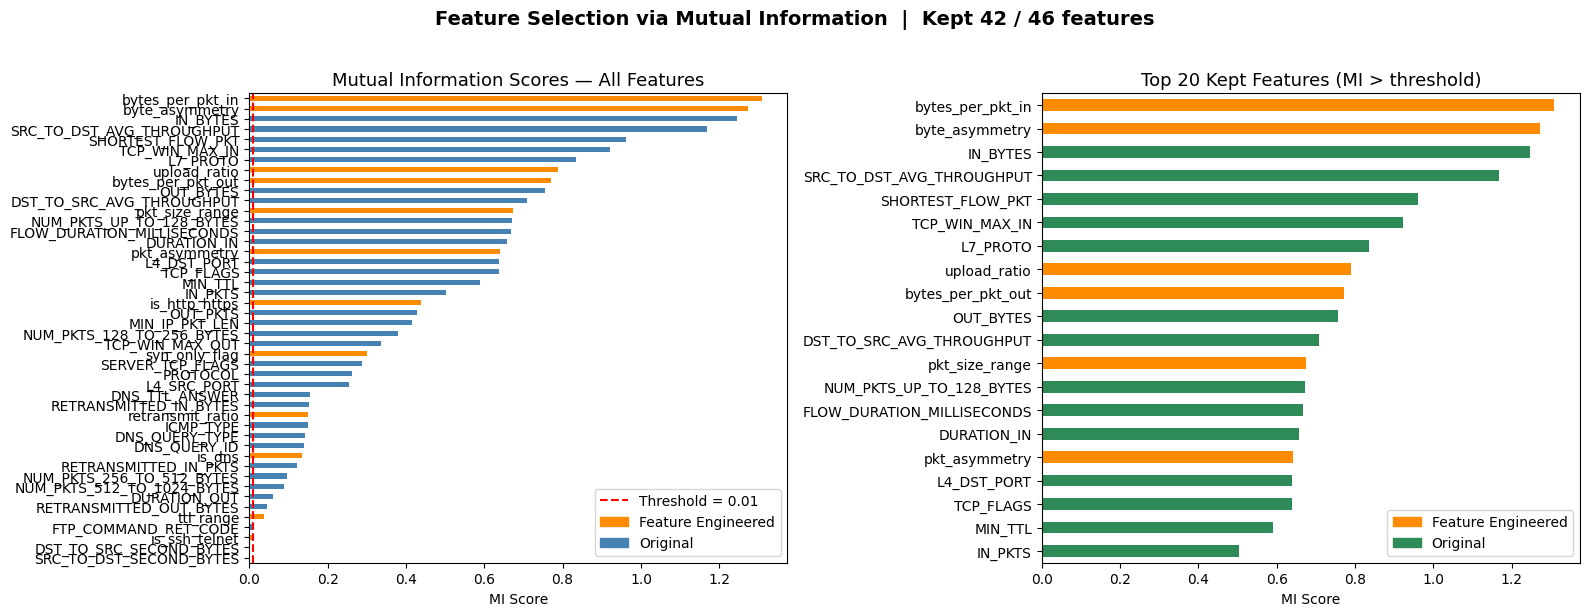

In [60]:
engineered = set([
    'bytes_per_pkt_in', 'bytes_per_pkt_out', 'upload_ratio',
    'byte_asymmetry', 'pkt_asymmetry', 'is_http_https',
    'is_ssh_telnet', 'is_dns', 'ttl_range', 'syn_only_flag',
    'pkt_size_range', 'retransmit_ratio', 'retransmit_pkt_ratio'
])

def bar_colors(index, base='steelblue', highlight='darkorange'):
    return [highlight if f in engineered else base for f in index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: all features ranked
sorted_all = mi_series.sort_values(ascending=True)
sorted_all.plot(
    kind='barh', ax=axes[0],
    color=bar_colors(sorted_all.index),
    edgecolor='none'
)
axes[0].axvline(mi_threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {mi_threshold}')
axes[0].set_title('Mutual Information Scores — All Features', fontsize=13)
axes[0].set_xlabel('MI Score')


axes[0].legend(handles=[
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {mi_threshold}'),
    Patch(color='darkorange', label='Feature Engineered'),
    Patch(color='steelblue',  label='Original'),
])

# Right: top 20 kept features
top20 = mi_series[cols_to_keep_mi].sort_values(ascending=True).tail(20)
top20.plot(
    kind='barh', ax=axes[1],
    color=bar_colors(top20.index, base='seagreen'),
    edgecolor='none'
)
axes[1].set_title('Top 20 Kept Features (MI > threshold)', fontsize=13)
axes[1].set_xlabel('MI Score')
axes[1].legend(handles=[
    Patch(color='darkorange', label='Feature Engineered'),
    Patch(color='seagreen',   label='Original'),
])

plt.suptitle(f'Feature Selection via Mutual Information  |  Kept {len(cols_to_keep_mi)} / {len(mi_series)} features',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{plots_dir}/mi_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()


##  Save all data

In [48]:
## Save full dataset arrays
## Model 1 — binary classifier    : uses X_train / y_train_bin
## Model 2 — full multiclass      : uses X_train / y_train_multi  (all 21 classes)
np.save(f'{artefacts_dir}/X_train.npy',       X_train)
np.save(f'{artefacts_dir}/X_val.npy',         X_val)
np.save(f'{artefacts_dir}/X_test.npy',        X_test)
np.save(f'{artefacts_dir}/y_train_bin.npy',   y_train_bin)
np.save(f'{artefacts_dir}/y_val_bin.npy',     y_val_bin)
np.save(f'{artefacts_dir}/y_test_bin.npy',    y_test_bin)
np.save(f'{artefacts_dir}/y_train_multi.npy', y_train_multi)
np.save(f'{artefacts_dir}/y_val_multi.npy',   y_val_multi)
np.save(f'{artefacts_dir}/y_test_multi.npy',  y_test_multi)


## Update -----> Attacks only data for training multi class models to be used as a second layer after the binary model

In [49]:
attack_train_mask = y_train_bin == 1
attack_val_mask   = y_val_bin   == 1
attack_test_mask  = y_test_bin  == 1

X_train_att       = X_train[attack_train_mask]
y_train_att_multi = y_train_multi[attack_train_mask]

X_val_att         = X_val[attack_val_mask]
y_val_att_multi   = y_val_multi[attack_val_mask]

X_test_att        = X_test[attack_test_mask]
y_test_att_multi  = y_test_multi[attack_test_mask]

In [50]:
print(f"  Train : {X_train_att.shape}")
print(f"  Val   : {X_val_att.shape}")
print(f"  Test  : {X_test_att.shape}")

  Train : (9213731, 42)
  Val   : (3071244, 42)
  Test  : (3071244, 42)


## Class distribution

In [51]:
unique, counts = np.unique(y_train_att_multi, return_counts=True)
print("attack-only training class distribution:")
for cls, cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
    name = le.inverse_transform([cls])[0]
    pct  = cnt / len(y_train_att_multi) * 100
    print(f"  {name} {cnt}   {pct:.3f}%")


attack-only training class distribution:
  DDoS 3932863   42.685%
  DoS 3264371   35.429%
  scanning 605441   6.571%
  Reconnaissance 499094   5.417%
  xss 485707   5.272%
  password 214708   2.330%
  injection 133775   1.452%
  Brute Force 24497   0.266%
  Infilteration 22939   0.249%
  Bot 11759   0.128%
  Exploits 5951   0.065%
  Fuzzers 4151   0.045%
  Backdoor 3496   0.038%
  Generic 1933   0.021%
  mitm 1486   0.016%
  ransomware 621   0.007%
  Theft 422   0.005%
  Shellcode 229   0.002%
  Analysis 227   0.002%
  Worms 61   0.001%


## class weights for attack-only distribution

In [53]:
classes_att = np.unique(y_train_att_multi)
weights_att = compute_class_weight(
    class_weight='balanced',
    classes=classes_att,
    y=y_train_att_multi
)
class_weight_att_dict = dict(zip(classes_att, weights_att))
joblib.dump(class_weight_att_dict, f'{artefacts_dir}/class_weights_att.pkl')

['/kaggle/working/artefacts/class_weights_att.pkl']

## Save attack-only data

In [54]:
np.save(f'{artefacts_dir}/X_train_att.npy',       X_train_att)
np.save(f'{artefacts_dir}/X_val_att.npy',         X_val_att)
np.save(f'{artefacts_dir}/X_test_att.npy',        X_test_att)
np.save(f'{artefacts_dir}/y_train_att_multi.npy', y_train_att_multi)
np.save(f'{artefacts_dir}/y_val_att_multi.npy',   y_val_att_multi)
np.save(f'{artefacts_dir}/y_test_att_multi.npy',  y_test_att_multi)

## Saving The Artefacts

In [62]:
from IPython.display import FileLink, display
import shutil, os

plots_zip = 'preprocessing_plots.zip'
if os.path.exists('/kaggle/working/plots_preprocessing'):
    shutil.make_archive('preprocessing_plots', 'zip', '/kaggle/working/plots_preprocessing')
    print("Plots")
    display(FileLink(plots_zip))
else:
    print(" plots_preprocessing not found")


artefacts_zip = 'preprocessing_artefacts.zip'
if os.path.exists('/kaggle/working/artefacts'):
    shutil.make_archive('preprocessing_artefacts', 'zip', '/kaggle/working/artefacts')
    print("Artefacts ")
    display(FileLink(artefacts_zip))
else:
    print(" artefacts not found")

Plots


/kaggle/working/preprocessing_plots.zip

Artefacts 


/kaggle/working/preprocessing_artefacts.zip